# Calibration Analysis and Temperature Scaling — Run 2

## Objective

This notebook evaluates the probabilistic calibration of the trained 3D ResNet-18 PDAC classifier (Run 2 baseline) and applies temperature scaling to it.

Calibration answers a different question than discrimination (AUC, F1, accuracy):

> When the model outputs a probability of 0.80, does the event actually occur about 80% of the time?

A model can discriminate well (rank PDAC cases above non-PDAC cases correctly) while still being poorly calibrated (its stated confidence does not match its empirical reliability). Both properties matter for a model intended to eventually support clinical decision-making.

This is a **post-hoc analysis of already-saved predictions**. It does not load the trained 3D model, does not require a GPU, and does not alter the Run 2 checkpoint in any way.

## Methodology

1. Load `validation_predictions.csv` and `test_predictions.csv` produced by the Run 2 training notebook.
2. Recover per-case logits from the saved probabilities (see note below).
3. Compute uncalibrated calibration metrics (AUC, Brier score, NLL, ECE) on the test set.
4. Fit a single temperature parameter *T* using the validation set.
5. Apply the fitted temperature to the test set and recompute the same metrics.
6. Compare uncalibrated vs. calibrated results, with paired bootstrap confidence intervals for both conditions and for the change between them.

## Important methodological notes

- **What "never touching the test set for fitting" actually means**: the test set is never used to fit the temperature parameter or any other calibration parameter. It **is** evaluated twice -- once before calibration (to establish the uncalibrated baseline) and once after (to evaluate the calibrated probabilities) -- on the same held-out cases, for a direct before/after comparison. This is not leakage, since nothing is optimized using test labels, but it is more accurate to say the test set is evaluated twice than to say it is "touched only once."

- **Validation set reuse (limitation, stated explicitly)**: the Run 2 model checkpoint was already selected using validation loss on the full 338-case validation set. Temperature scaling below is then fit using that same validation set. This is standard practice -- the original temperature scaling paper (Guo et al., 2017, *On Calibration of Modern Neural Networks*) fits temperature on the same validation set used for other model decisions -- and it does **not** constitute test-set leakage. But the validation set is doing two jobs (checkpoint selection, then calibration fitting), which can make the calibration estimate mildly optimistic relative to a fully independent calibration set. This notebook does not attempt to retroactively re-split validation to "fix" this: the original checkpoint selection already used the full validation set, so a new split now would not undo that, and would introduce an unaudited split on an already-modest 338-case set for no real benefit. It is stated here as a limitation, not corrected after the fact.

- **Recovering logits from saved probabilities**: raw logits were not saved during Run 2 -- only the final sigmoid probabilities were. They are reconstructed here using the inverse-logit transformation, `logit = log(p / (1-p))`. Probabilities are clipped only where necessary for numerical stability (values extremely close to 0 or 1) before inversion. A reconstruction sanity check below confirms the recovered logits reproduce the original saved probabilities to within floating-point precision.

- **Temperature scaling and fixed-threshold metrics**: for standard temperature scaling, `p_calibrated = sigmoid(logit / T)` with `T > 0`. Since `sign(logit / T) == sign(logit)` for any positive `T`, a fixed 0.5 probability threshold corresponds to `logit >= 0` both before and after scaling. This means accuracy, precision, recall, specificity, F1, and the confusion matrix are **mathematically guaranteed unchanged** at a fixed 0.5 threshold -- this is verified directly below, not just asserted. AUC is also unchanged, since the transformation is strictly monotonic and preserves case ranking. Only the calibration metrics (Brier score, NLL, ECE) can change.


In [12]:
# ============================================================
# CELL 1 — IMPORTS AND CONFIGURATION
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, brier_score_loss, log_loss, confusion_matrix,
)

# ------------------------------------------------------------
# Paths — UPDATE THESE to wherever you placed the downloaded
# Kaggle output (results_run2/validation_predictions.csv and
# results_run2/test_predictions.csv).
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"D:\Pancreatic_Cancer_Thesis")
RESULTS_DIR = PROJECT_ROOT / "reports" / "results_run2"   

VAL_PREDICTIONS_PATH = RESULTS_DIR / "validation_predictions.csv"
TEST_PREDICTIONS_PATH = RESULTS_DIR / "test_predictions.csv"

CALIBRATION_OUTPUT_DIR = PROJECT_ROOT / "reports" / "calibration_analysis"
CALIBRATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

EPS = 1e-7            # numerical stability clip for probabilities near 0/1
N_BINS = 10            # equal-width bins for ECE / reliability diagram
N_BOOTSTRAP = 2000     # bootstrap resamples for confidence intervals

# Metric directionality, used for interpretation text throughout.
LOWER_IS_BETTER = {"auc": False, "brier": True, "nll": True, "ece": True}

print("=" * 70)
print("CALIBRATION ANALYSIS — CONFIGURATION")
print("=" * 70)
print("Validation predictions:", VAL_PREDICTIONS_PATH)
print("  exists:", VAL_PREDICTIONS_PATH.exists())
print("Test predictions      :", TEST_PREDICTIONS_PATH)
print("  exists:", TEST_PREDICTIONS_PATH.exists())
print("Output directory      :", CALIBRATION_OUTPUT_DIR)
print("Bins for ECE          :", N_BINS)
print("Bootstrap resamples   :", N_BOOTSTRAP)
print(
    "\nThis notebook is CPU-only and does not load the trained model, "
    "run inference, or require a GPU -- it analyzes already-saved predictions."
)


CALIBRATION ANALYSIS — CONFIGURATION
Validation predictions: D:\Pancreatic_Cancer_Thesis\reports\results_run2\validation_predictions.csv
  exists: True
Test predictions      : D:\Pancreatic_Cancer_Thesis\reports\results_run2\test_predictions.csv
  exists: True
Output directory      : D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis
Bins for ECE          : 10
Bootstrap resamples   : 2000

This notebook is CPU-only and does not load the trained model, run inference, or require a GPU -- it analyzes already-saved predictions.


## Load predictions

Both CSVs are expected to contain, at minimum: `study_id`, `label` (0/1), `probability` (the model's sigmoid output for the PDAC class).

In [13]:
# ============================================================
# CELL 2 — LOAD AND VALIDATE PREDICTIONS
# ============================================================

if not VAL_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Validation predictions not found at {VAL_PREDICTIONS_PATH}.\n"
        "Download results_run2/validation_predictions.csv from the Kaggle "
        "notebook's Output tab and place it here, or update RESULTS_DIR above."
    )
if not TEST_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Test predictions not found at {TEST_PREDICTIONS_PATH}.\n"
        "Download results_run2/test_predictions.csv from the Kaggle "
        "notebook's Output tab and place it here, or update RESULTS_DIR above."
    )

val_df = pd.read_csv(VAL_PREDICTIONS_PATH)
test_df = pd.read_csv(TEST_PREDICTIONS_PATH)

required_columns = {"study_id", "label", "probability"}

for name, df in [("Validation", val_df), ("Test", test_df)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{name} predictions missing columns: {missing}")
    if df["probability"].isna().any():
        raise ValueError(f"{name} predictions contain NaN probabilities.")
    if not df["probability"].between(0.0, 1.0).all():
        raise ValueError(f"{name} predictions contain probabilities outside [0, 1].")
    if not set(df["label"].unique()).issubset({0, 1}):
        raise ValueError(f"{name} predictions contain labels other than 0/1.")

print("=" * 70)
print("PREDICTIONS LOADED")
print("=" * 70)
print(f"Validation cases: {len(val_df)}")
print(f"  PDAC: {int((val_df['label'] == 1).sum())}, "
      f"non-PDAC: {int((val_df['label'] == 0).sum())}")
print(f"\nTest cases      : {len(test_df)}")
print(f"  PDAC: {int((test_df['label'] == 1).sum())}, "
      f"non-PDAC: {int((test_df['label'] == 0).sum())}")

display(val_df.head())
display(test_df.head())


PREDICTIONS LOADED
Validation cases: 338
  PDAC: 100, non-PDAC: 238

Test cases      : 337
  PDAC: 103, non-PDAC: 234


,study_id,label,probability
0,100010_00001,0,0.001720
1,100011_00001,1,0.986816
2,100012_00001,0,0.000011
3,100017_00001,0,0.022461
4,100035_00001,0,1.000000


,study_id,label,probability
0,100003_00001,1,0.895996
1,100006_00001,0,0.971191
2,100014_00001,0,0.012146
3,100016_00001,1,0.137085
4,100022_00001,0,0.000040


## Recover logits from saved probabilities

Raw logits were not saved during Run 2, so they are reconstructed here from the stored sigmoid probabilities using the inverse-logit transformation:

`logit = log(p / (1 - p))`

Probabilities are clipped only where necessary for numerical stability (extremely close to 0 or 1) before inversion. The cell below verifies the reconstruction is consistent with the originally saved probabilities to within floating-point precision.

In [14]:
# ============================================================
# CELL 3 — RECOVER LOGITS FROM PROBABILITIES
# ============================================================

def probability_to_logit(p, eps=EPS):
    p_clipped = np.clip(p, eps, 1 - eps)
    return np.log(p_clipped / (1 - p_clipped))


val_df["logit"] = probability_to_logit(val_df["probability"].values)
test_df["logit"] = probability_to_logit(test_df["probability"].values)

# Reconstruction sanity check: sigmoid(recovered logit) should reproduce
# the originally saved probability to within floating-point precision.
reconstructed_val = 1 / (1 + np.exp(-val_df["logit"].values))
reconstructed_test = 1 / (1 + np.exp(-test_df["logit"].values))

max_error_val = np.max(np.abs(reconstructed_val - val_df["probability"].values))
max_error_test = np.max(np.abs(reconstructed_test - test_df["probability"].values))

print("Max reconstruction error (validation):", max_error_val)
print("Max reconstruction error (test)      :", max_error_test)

assert max_error_val < 1e-5, "Logit recovery inconsistent on validation set."
assert max_error_test < 1e-5, "Logit recovery inconsistent on test set."

print("\n✓ Logits recovered; reconstruction matches saved probabilities within floating-point precision.")
display(val_df[["study_id", "label", "probability", "logit"]].head())


Max reconstruction error (validation): 1.0000000005838672e-07
Max reconstruction error (test)      : 1.0000000005838672e-07

✓ Logits recovered; reconstruction matches saved probabilities within floating-point precision.


,study_id,label,probability,logit
0,100010_00001,0,0.001720,-6.363460
1,100011_00001,1,0.986816,4.315511
2,100012_00001,0,0.000011,-11.399079
3,100017_00001,0,0.022461,-3.773261
4,100035_00001,0,1.000000,16.118096


## Calibration metrics

Four metrics are computed for both the uncalibrated and calibrated probabilities:

- **AUC** — discrimination (ranking quality); unaffected by temperature scaling.
- **Brier score** — mean squared error between predicted probability and true label; lower is better.
- **NLL (log loss)** — the quantity temperature scaling directly minimizes on the validation set; lower is better; a numerically stable implementation (clipped probabilities) is used.
- **ECE (Expected Calibration Error)** — computed using **10 equal-width probability bins** throughout this notebook. ECE is binning-dependent: it should be interpreted together with the reliability diagram and the Brier/NLL scores, not treated as a single universal property of the model independent of how it was computed.

In [15]:
# ============================================================
# CELL 4 — CALIBRATION METRIC FUNCTIONS
# ============================================================

def expected_calibration_error(labels, probabilities, n_bins=N_BINS):
    """ECE using n_bins equal-width probability bins. Binning-dependent
    by construction -- report together with reliability diagram / Brier / NLL."""
    labels = np.asarray(labels, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(probabilities, bin_edges[1:-1])

    n = len(labels)
    ece = 0.0
    bin_records = []

    for b in range(n_bins):
        mask = bin_indices == b
        bin_count = int(mask.sum())

        if bin_count == 0:
            bin_records.append({
                "bin": b, "bin_low": bin_edges[b], "bin_high": bin_edges[b + 1],
                "count": 0, "confidence": np.nan, "positive_frequency": np.nan,
            })
            continue

        bin_confidence = probabilities[mask].mean()
        bin_positive_frequency = labels[mask].mean()

        ece += (bin_count / n) * abs(bin_positive_frequency - bin_confidence)

        bin_records.append({
            "bin": b, "bin_low": bin_edges[b], "bin_high": bin_edges[b + 1],
            "count": bin_count, "confidence": bin_confidence,
            "positive_frequency": bin_positive_frequency,
        })

    return ece, pd.DataFrame(bin_records)


def negative_log_likelihood(labels, probabilities, eps=EPS):
    """Numerically stable NLL / log loss: probabilities are clipped away
    from exactly 0 or 1 before taking the log, avoiding -inf."""
    probabilities_clipped = np.clip(probabilities, eps, 1 - eps)
    return log_loss(labels, probabilities_clipped, labels=[0, 1])


def compute_all_metrics(labels, probabilities, threshold=0.5, n_bins=N_BINS):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)

    ece, bin_table = expected_calibration_error(labels, probabilities, n_bins)
    brier = brier_score_loss(labels, probabilities)
    nll = negative_log_likelihood(labels, probabilities)
    auc = roc_auc_score(labels, probabilities) if len(np.unique(labels)) == 2 else float("nan")
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    specificity = tn / max(tn + fp, 1)

    metrics = {
        "auc": auc, "brier": brier, "nll": nll, "ece": ece,
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "specificity": specificity, "f1": f1, "n_cases": len(labels),
    }
    return metrics, bin_table, predictions


print("✓ Calibration metric functions defined (AUC, Brier, NLL, ECE + threshold=0.5 classification metrics).")


✓ Calibration metric functions defined (AUC, Brier, NLL, ECE + threshold=0.5 classification metrics).


## Uncalibrated metrics — test set

These are the "before" numbers: raw calibration behavior prior to any correction, computed once directly on the test set.

In [16]:
# ============================================================
# CELL 5 — UNCALIBRATED METRICS (TEST SET)
# ============================================================

uncalibrated_metrics, uncalibrated_bins, uncalibrated_predictions = compute_all_metrics(
    test_df["label"], test_df["probability"], threshold=0.5,
)

print("=" * 70)
print("UNCALIBRATED TEST SET METRICS")
print("=" * 70)
for key, value in uncalibrated_metrics.items():
    if key == "n_cases":
        print(f"{key:12s}: {value}")
    else:
        print(f"{key:12s}: {value:.4f}")

print(
    f"\nNote: ECE computed using {N_BINS} equal-width bins on "
    f"{uncalibrated_metrics['n_cases']} test cases. ECE is binning-dependent -- "
    "interpret alongside the reliability diagram and Brier/NLL scores below, "
    "not as a single universal property of the model."
)

print("\nPer-bin breakdown:")
display(uncalibrated_bins)


UNCALIBRATED TEST SET METRICS
auc         : 0.8556
brier       : 0.1577
nll         : 0.6136
ece         : 0.1128
accuracy    : 0.8071
precision   : 0.6863
recall      : 0.6796
specificity : 0.8632
f1          : 0.6829
n_cases     : 337

Note: ECE computed using 10 equal-width bins on 337 test cases. ECE is binning-dependent -- interpret alongside the reliability diagram and Brier/NLL scores below, not as a single universal property of the model.

Per-bin breakdown:


,bin,bin_low,bin_high,count,confidence,positive_frequency
0,0,0.0,0.1,190,0.014517,0.094737
1,1,0.1,0.2,18,0.144311,0.277778
2,2,0.2,0.3,14,0.252101,0.357143
3,3,0.3,0.4,8,0.351746,0.375000
4,4,0.4,0.5,5,0.456641,0.400000
5,5,0.5,0.6,11,0.549139,0.454545
6,6,0.6,0.7,11,0.643910,0.636364
7,7,0.7,0.8,10,0.753564,0.800000
8,8,0.8,0.9,12,0.854167,0.750000
9,9,0.9,1.0,58,0.975897,0.706897


## Reliability diagram — before calibration

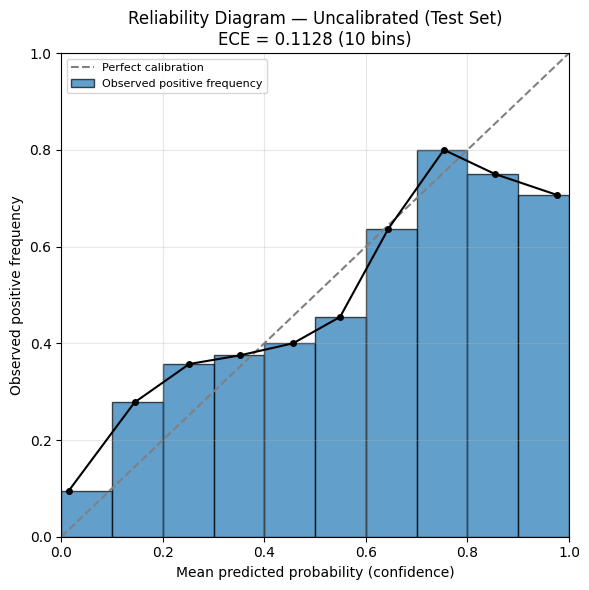

Saved: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis\reliability_diagram_uncalibrated.png


In [17]:
# ============================================================
# CELL 6 — RELIABILITY DIAGRAM (UNCALIBRATED)
# ============================================================

def plot_reliability_diagram(bin_table, title, ax=None, color="tab:blue"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

    valid = bin_table.dropna(subset=["confidence", "positive_frequency"])
    bin_centers = (valid["bin_low"] + valid["bin_high"]) / 2

    ax.bar(
        bin_centers, valid["positive_frequency"], width=1.0 / N_BINS, edgecolor="black",
        alpha=0.7, color=color, label="Observed positive frequency",
    )
    ax.plot(valid["confidence"], valid["positive_frequency"], "o-", color="black", markersize=4)

    ax.set_xlabel("Mean predicted probability (confidence)")
    ax.set_ylabel("Observed positive frequency")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)
    return ax


fig, ax = plt.subplots(figsize=(6, 6))
plot_reliability_diagram(
    uncalibrated_bins,
    f"Reliability Diagram — Uncalibrated (Test Set)\nECE = {uncalibrated_metrics['ece']:.4f} ({N_BINS} bins)",
    ax=ax,
)
plt.tight_layout()

uncal_plot_path = CALIBRATION_OUTPUT_DIR / "reliability_diagram_uncalibrated.png"
plt.savefig(uncal_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", uncal_plot_path)


## Fit temperature scaling on the validation set

Temperature scaling fits a single scalar *T* that rescales the logits: `calibrated_logit = logit / T`. *T > 1* softens (reduces confidence of) predictions; *T < 1* sharpens them; *T ≈ 1* means the model was already close to well-calibrated. *T* is fit by minimizing negative log-likelihood on the validation set.

**Limitation, stated explicitly here rather than corrected after the fact:** the Run 2 checkpoint (epoch 4) was already selected using validation loss computed on this same 338-case validation set. Fitting temperature on that same set means the validation data serves two roles -- model selection, then calibration fitting. This is standard practice (the original temperature scaling paper does the same) and does not use test labels or leak test information, but it can make the reported calibration quality mildly optimistic relative to a fully independent calibration set. No retroactive re-splitting is performed: the original checkpoint selection already used the full validation set, so a new split now would not undo that decision, and would introduce an unaudited split on an already-modest sample for no real correction of the underlying issue.

In [18]:
# ============================================================
# CELL 7 — FIT TEMPERATURE SCALING ON VALIDATION SET
# ============================================================

def temperature_nll(temperature, logits, labels):
    temperature = max(temperature, 1e-3)  # guard against non-positive values during optimization
    scaled_probabilities = 1 / (1 + np.exp(-logits / temperature))
    return negative_log_likelihood(labels, scaled_probabilities)


val_logits = val_df["logit"].values
val_labels = val_df["label"].values

optimization_result = minimize_scalar(
    temperature_nll,
    args=(val_logits, val_labels),
    bounds=(0.05, 10.0),
    method="bounded",
)

fitted_temperature = optimization_result.x

print("=" * 70)
print("TEMPERATURE SCALING FIT (VALIDATION SET)")
print("=" * 70)
print(f"Fitted temperature (T)   : {fitted_temperature:.4f}")
print(f"Validation NLL before    : {temperature_nll(1.0, val_logits, val_labels):.4f}")
print(f"Validation NLL after     : {temperature_nll(fitted_temperature, val_logits, val_labels):.4f}")

if fitted_temperature > 1.0:
    print(
        "\nT > 1: the model was overconfident on validation data. "
        "Temperature scaling will soften (reduce) predicted probabilities."
    )
elif fitted_temperature < 1.0:
    print(
        "\nT < 1: the model was underconfident on validation data. "
        "Temperature scaling will sharpen (increase) predicted probabilities."
    )
else:
    print("\nT ≈ 1: the model was already close to well-calibrated on validation data.")

print(
    "\nReminder: this temperature was fit using the same validation set "
    "already used for Run 2 checkpoint selection (see limitation above)."
)


TEMPERATURE SCALING FIT (VALIDATION SET)
Fitted temperature (T)   : 2.6770
Validation NLL before    : 0.6354
Validation NLL after     : 0.4442

T > 1: the model was overconfident on validation data. Temperature scaling will soften (reduce) predicted probabilities.

Reminder: this temperature was fit using the same validation set already used for Run 2 checkpoint selection (see limitation above).


## Apply fitted temperature to the test set

The test set is never used to fit the temperature parameter. It is evaluated before calibration (Cell 5, above) and after calibration (below) on the same held-out cases, for a direct comparison.

This cell also verifies directly -- not just by assertion in prose -- that accuracy, precision, recall, specificity, F1, and the confusion matrix are unchanged at the fixed 0.5 threshold, as guaranteed by the sign-preserving property of dividing logits by a positive temperature.

In [19]:
# ============================================================
# CELL 8 — APPLY TEMPERATURE TO TEST SET AND RECOMPUTE METRICS
# ============================================================

test_logits = test_df["logit"].values
test_df["calibrated_probability"] = 1 / (1 + np.exp(-test_logits / fitted_temperature))

calibrated_metrics, calibrated_bins, calibrated_predictions = compute_all_metrics(
    test_df["label"], test_df["calibrated_probability"], threshold=0.5,
)

print("=" * 70)
print(f"CALIBRATED TEST SET METRICS (T = {fitted_temperature:.4f})")
print("=" * 70)
for key, value in calibrated_metrics.items():
    if key == "n_cases":
        print(f"{key:12s}: {value}")
    else:
        print(f"{key:12s}: {value:.4f}")

# ------------------------------------------------------------
# Verify threshold-invariant metrics are actually unchanged, not
# just close. Since sign(logit / T) == sign(logit) for T > 0, the
# 0.5-threshold predictions are mathematically guaranteed identical.
# ------------------------------------------------------------

predictions_identical = np.array_equal(uncalibrated_predictions, calibrated_predictions)

print("\n" + "=" * 70)
print("THRESHOLD-INVARIANCE CHECK (0.5 threshold)")
print("=" * 70)
print(f"Uncalibrated and calibrated predictions identical: {predictions_identical}")

if predictions_identical:
    print(
        "✓ Confirmed: accuracy, precision, recall, specificity, F1, and the "
        "confusion matrix are unchanged by temperature scaling at this "
        "threshold, as expected mathematically (sign of the logit is "
        "preserved by dividing by a positive temperature)."
    )
else:
    n_flipped = int((uncalibrated_predictions != calibrated_predictions).sum())
    print(
        f"NOTE: {n_flipped} prediction(s) differ. Given the mathematical "
        "guarantee above, this can only be a negligible floating-point "
        "boundary effect (a case landing extremely close to logit == 0), "
        "not a genuine calibration effect -- it should not be interpreted "
        "as temperature scaling changing classification behavior."
    )

for metric_name in ["accuracy", "precision", "recall", "specificity", "f1"]:
    diff = calibrated_metrics[metric_name] - uncalibrated_metrics[metric_name]
    print(f"  {metric_name:12s} uncalibrated={uncalibrated_metrics[metric_name]:.6f}  "
          f"calibrated={calibrated_metrics[metric_name]:.6f}  diff={diff:+.2e}")

# ------------------------------------------------------------
# Before-vs-after comparison table (all metrics)
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("UNCALIBRATED vs. CALIBRATED — TEST SET COMPARISON")
print("=" * 70)

comparison_df = pd.DataFrame({
    "Uncalibrated": uncalibrated_metrics,
    "Calibrated": calibrated_metrics,
}).T
display(comparison_df)

print("\nChanges (calibrated − uncalibrated; direction of 'improved' depends on the metric):")
for metric_name in ["auc", "brier", "nll", "ece"]:
    delta = calibrated_metrics[metric_name] - uncalibrated_metrics[metric_name]
    lower_is_better = LOWER_IS_BETTER[metric_name]
    if metric_name == "auc":
        note = "(expected ≈ 0 -- monotonic transform preserves ranking)"
    else:
        direction = "improved" if (delta < 0) == lower_is_better else "worsened"
        note = f"({direction}; lower is better for this metric)" if lower_is_better else f"({direction})"
    print(f"  {metric_name.upper():6s}: {delta:+.4f}  {note}")


CALIBRATED TEST SET METRICS (T = 2.6770)
auc         : 0.8556
brier       : 0.1423
nll         : 0.4413
ece         : 0.0510
accuracy    : 0.8071
precision   : 0.6863
recall      : 0.6796
specificity : 0.8632
f1          : 0.6829
n_cases     : 337

THRESHOLD-INVARIANCE CHECK (0.5 threshold)
Uncalibrated and calibrated predictions identical: True
✓ Confirmed: accuracy, precision, recall, specificity, F1, and the confusion matrix are unchanged by temperature scaling at this threshold, as expected mathematically (sign of the logit is preserved by dividing by a positive temperature).
  accuracy     uncalibrated=0.807122  calibrated=0.807122  diff=+0.00e+00
  precision    uncalibrated=0.686275  calibrated=0.686275  diff=+0.00e+00
  recall       uncalibrated=0.679612  calibrated=0.679612  diff=+0.00e+00
  specificity  uncalibrated=0.863248  calibrated=0.863248  diff=+0.00e+00
  f1           uncalibrated=0.682927  calibrated=0.682927  diff=+0.00e+00

UNCALIBRATED vs. CALIBRATED — TEST SET COM

,auc,brier,nll,ece,accuracy,precision,recall,specificity,f1,n_cases
Uncalibrated,0.855634,0.157716,0.613645,0.112831,0.807122,0.686275,0.679612,0.863248,0.682927,337.0
Calibrated,0.855634,0.142328,0.441260,0.050971,0.807122,0.686275,0.679612,0.863248,0.682927,337.0



Changes (calibrated − uncalibrated; direction of 'improved' depends on the metric):
  AUC   : +0.0000  (expected ≈ 0 -- monotonic transform preserves ranking)
  BRIER : -0.0154  (improved; lower is better for this metric)
  NLL   : -0.1724  (improved; lower is better for this metric)
  ECE   : -0.0619  (improved; lower is better for this metric)


## Reliability diagram — before vs. after calibration

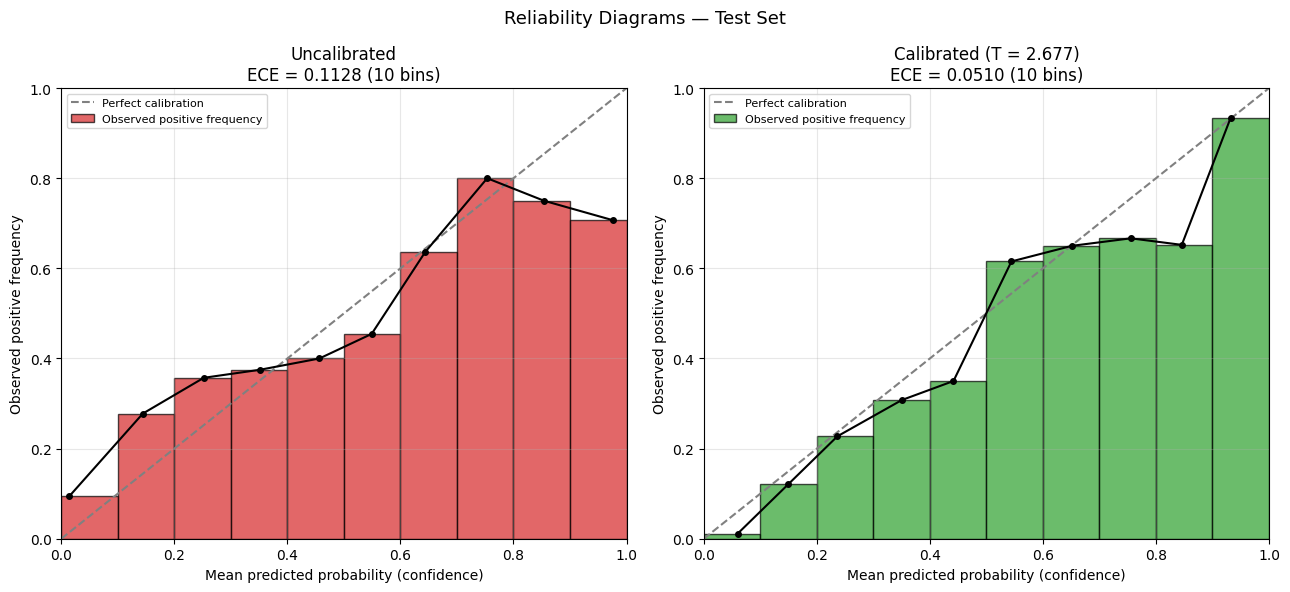

Saved: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis\reliability_diagram_comparison.png


In [20]:
# ============================================================
# CELL 9 — RELIABILITY DIAGRAMS: BEFORE vs AFTER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

plot_reliability_diagram(
    uncalibrated_bins,
    f"Uncalibrated\nECE = {uncalibrated_metrics['ece']:.4f} ({N_BINS} bins)",
    ax=axes[0], color="tab:red",
)
plot_reliability_diagram(
    calibrated_bins,
    f"Calibrated (T = {fitted_temperature:.3f})\nECE = {calibrated_metrics['ece']:.4f} ({N_BINS} bins)",
    ax=axes[1], color="tab:green",
)

plt.suptitle("Reliability Diagrams — Test Set", fontsize=13)
plt.tight_layout()

comparison_plot_path = CALIBRATION_OUTPUT_DIR / "reliability_diagram_comparison.png"
plt.savefig(comparison_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", comparison_plot_path)


## Paired bootstrap confidence intervals

A single point estimate on 337 test cases carries real sampling uncertainty, especially with only ~103 PDAC-positive cases. This section uses **paired bootstrap resampling**: on each of `N_BOOTSTRAP` iterations, one set of case indices is drawn with replacement, and *both* the uncalibrated and calibrated metric are computed on that same resample. This is done for AUC, Brier score, NLL, and ECE, for **both** the uncalibrated and calibrated probabilities, and the resulting per-resample differences give a proper confidence interval for the *change* due to calibration -- not just two separately-estimated intervals to eyeball against each other.

For every metric, the reported point estimate is the value computed once on the actual observed test set (not the mean of the bootstrap replicates) -- the bootstrap is used only to derive the confidence interval around that real, observed value.

In [21]:
# ============================================================
# CELL 10 — PAIRED BOOTSTRAP: UNCALIBRATED, CALIBRATED, AND DELTA
# ============================================================

def paired_bootstrap(labels, probs_uncalibrated, probs_calibrated, metric_fn,
                      n_bootstrap=N_BOOTSTRAP, seed=SEED):
    """
    Returns a dict with point estimates and 95% CIs for the uncalibrated
    metric, the calibrated metric, and their difference (calibrated -
    uncalibrated), using the SAME resampled case indices for both
    conditions on each bootstrap iteration (paired resampling).

    Point estimates are computed once on the full, actual test set --
    not derived from the bootstrap replicates.
    """
    labels = np.asarray(labels)
    probs_uncalibrated = np.asarray(probs_uncalibrated)
    probs_calibrated = np.asarray(probs_calibrated)
    n = len(labels)

    point_uncalibrated = metric_fn(labels, probs_uncalibrated)
    point_calibrated = metric_fn(labels, probs_calibrated)
    point_delta = point_calibrated - point_uncalibrated

    rng = np.random.default_rng(seed)
    uncal_scores, cal_scores, delta_scores = [], [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        sample_labels = labels[idx]

        if len(np.unique(sample_labels)) < 2:
            continue  # AUC undefined for a single-class resample

        u = metric_fn(sample_labels, probs_uncalibrated[idx])
        c = metric_fn(sample_labels, probs_calibrated[idx])

        uncal_scores.append(u)
        cal_scores.append(c)
        delta_scores.append(c - u)

    uncal_ci = np.percentile(uncal_scores, [2.5, 97.5])
    cal_ci = np.percentile(cal_scores, [2.5, 97.5])
    delta_ci = np.percentile(delta_scores, [2.5, 97.5])

    return {
        "uncalibrated_point": point_uncalibrated,
        "uncalibrated_ci_low": uncal_ci[0], "uncalibrated_ci_high": uncal_ci[1],
        "calibrated_point": point_calibrated,
        "calibrated_ci_low": cal_ci[0], "calibrated_ci_high": cal_ci[1],
        "delta_point": point_delta,
        "delta_ci_low": delta_ci[0], "delta_ci_high": delta_ci[1],
    }


def auc_metric(labels, probs):
    return roc_auc_score(labels, probs)


def brier_metric(labels, probs):
    return brier_score_loss(labels, probs)


def nll_metric_fn(labels, probs):
    return negative_log_likelihood(labels, probs)


def ece_metric(labels, probs):
    ece, _ = expected_calibration_error(labels, probs, n_bins=N_BINS)
    return ece


metric_functions = {
    "auc": auc_metric, "brier": brier_metric, "nll": nll_metric_fn, "ece": ece_metric,
}

print("=" * 70)
print(f"PAIRED BOOTSTRAP 95% CONFIDENCE INTERVALS ({N_BOOTSTRAP} resamples)")
print("=" * 70)

bootstrap_records = []

for metric_name, fn in metric_functions.items():
    result = paired_bootstrap(
        test_df["label"], test_df["probability"], test_df["calibrated_probability"], fn,
    )
    result["metric"] = metric_name
    result["lower_is_better"] = LOWER_IS_BETTER[metric_name]
    bootstrap_records.append(result)

    print(f"\n{metric_name.upper()} (lower is better: {LOWER_IS_BETTER[metric_name]}):")
    print(
        f"  Uncalibrated: {result['uncalibrated_point']:.4f}  "
        f"(95% CI: [{result['uncalibrated_ci_low']:.4f}, {result['uncalibrated_ci_high']:.4f}])"
    )
    print(
        f"  Calibrated  : {result['calibrated_point']:.4f}  "
        f"(95% CI: [{result['calibrated_ci_low']:.4f}, {result['calibrated_ci_high']:.4f}])"
    )
    print(
        f"  Delta (cal - uncal): {result['delta_point']:+.4f}  "
        f"(95% CI: [{result['delta_ci_low']:+.4f}, {result['delta_ci_high']:+.4f}])"
    )

bootstrap_df = pd.DataFrame(bootstrap_records).set_index("metric")

print(
    "\n(All point estimates above are computed once on the actual observed "
    "test set and match the values reported in Cells 5 and 8 -- the bootstrap "
    "resampling is used only to derive confidence intervals around those "
    "observed values, not to replace them. Negative Delta CI values for "
    "Brier/NLL/ECE indicate improvement; for AUC, a delta CI spanning zero "
    "confirms discrimination was not meaningfully affected, as expected.)"
)

display(bootstrap_df)


PAIRED BOOTSTRAP 95% CONFIDENCE INTERVALS (2000 resamples)

AUC (lower is better: False):
  Uncalibrated: 0.8556  (95% CI: [0.8091, 0.8943])
  Calibrated  : 0.8556  (95% CI: [0.8091, 0.8943])
  Delta (cal - uncal): +0.0000  (95% CI: [+0.0000, +0.0000])

BRIER (lower is better: True):
  Uncalibrated: 0.1577  (95% CI: [0.1265, 0.1928])
  Calibrated  : 0.1423  (95% CI: [0.1218, 0.1658])
  Delta (cal - uncal): -0.0154  (95% CI: [-0.0282, -0.0033])

NLL (lower is better: True):
  Uncalibrated: 0.6136  (95% CI: [0.4786, 0.7704])
  Calibrated  : 0.4413  (95% CI: [0.3882, 0.5032])
  Delta (cal - uncal): -0.1724  (95% CI: [-0.2699, -0.0860])

ECE (lower is better: True):
  Uncalibrated: 0.1128  (95% CI: [0.0912, 0.1646])
  Calibrated  : 0.0510  (95% CI: [0.0457, 0.1043])
  Delta (cal - uncal): -0.0619  (95% CI: [-0.0936, -0.0071])

(All point estimates above are computed once on the actual observed test set and match the values reported in Cells 5 and 8 -- the bootstrap resampling is used only 

,uncalibrated_point,uncalibrated_ci_low,uncalibrated_ci_high,calibrated_point,calibrated_ci_low,calibrated_ci_high,delta_point,delta_ci_low,delta_ci_high,lower_is_better
metric,,,,,,,,,,
auc,0.855634,0.809105,0.894273,0.855634,0.809105,0.894273,0.000000,0.000000,0.000000,False
brier,0.157716,0.126509,0.192847,0.142328,0.121779,0.165765,-0.015388,-0.028151,-0.003335,True
nll,0.613645,0.478624,0.770429,0.441260,0.388177,0.503234,-0.172385,-0.269891,-0.085993,True
ece,0.112831,0.091221,0.164641,0.050971,0.045690,0.104330,-0.061860,-0.093613,-0.007073,True


## Save results

In [22]:
# ============================================================
# CELL 11 — SAVE CALIBRATION RESULTS
# ============================================================

# Full test predictions, uncalibrated and calibrated side by side.
test_output_path = CALIBRATION_OUTPUT_DIR / "test_predictions_calibrated.csv"
test_df[["study_id", "label", "probability", "calibrated_probability"]].to_csv(
    test_output_path, index=False
)
print("Saved:", test_output_path)

# Point-estimate comparison table (all metrics, uncalibrated vs calibrated).
summary_path = CALIBRATION_OUTPUT_DIR / "calibration_summary.csv"
comparison_df.to_csv(summary_path)
print("Saved:", summary_path)

# Paired bootstrap CIs: uncalibrated, calibrated, and delta, for AUC/Brier/NLL/ECE.
bootstrap_path = CALIBRATION_OUTPUT_DIR / "bootstrap_confidence_intervals.csv"
bootstrap_df.to_csv(bootstrap_path)
print("Saved:", bootstrap_path)

# Fitted temperature value, for reproducibility / reporting.
temperature_path = CALIBRATION_OUTPUT_DIR / "temperature_scaling_record.csv"
pd.DataFrame([{
    "fitted_temperature": fitted_temperature,
    "fit_set": "validation",
    "fit_n_cases": len(val_df),
    "eval_set": "test",
    "eval_n_cases": len(test_df),
    "n_bins_ece": N_BINS,
    "n_bootstrap": N_BOOTSTRAP,
    "seed": SEED,
    "validation_reused_for_checkpoint_selection_and_calibration": True,
}]).to_csv(temperature_path, index=False)
print("Saved:", temperature_path)

# ------------------------------------------------------------
# Clean, thesis-ready summary table: point estimates + CIs for the
# bootstrapped metrics (AUC/Brier/NLL/ECE), plus the threshold-based
# metrics (identical pre/post calibration, reported once with a note).
# ------------------------------------------------------------

thesis_summary_rows = []

for metric_name in ["auc", "brier", "nll", "ece"]:
    row = bootstrap_df.loc[metric_name]
    thesis_summary_rows.append({
        "metric": metric_name.upper(),
        "uncalibrated": f"{row['uncalibrated_point']:.4f} [{row['uncalibrated_ci_low']:.4f}, {row['uncalibrated_ci_high']:.4f}]",
        "calibrated": f"{row['calibrated_point']:.4f} [{row['calibrated_ci_low']:.4f}, {row['calibrated_ci_high']:.4f}]",
        "delta_95ci": f"{row['delta_point']:+.4f} [{row['delta_ci_low']:+.4f}, {row['delta_ci_high']:+.4f}]",
        "lower_is_better": row["lower_is_better"],
    })

for metric_name in ["accuracy", "precision", "recall", "specificity", "f1"]:
    thesis_summary_rows.append({
        "metric": metric_name.capitalize(),
        "uncalibrated": f"{uncalibrated_metrics[metric_name]:.4f}",
        "calibrated": f"{calibrated_metrics[metric_name]:.4f}",
        "delta_95ci": "identical by construction (fixed 0.5 threshold; see Cell 8 verification)",
        "lower_is_better": "n/a",
    })

thesis_summary_df = pd.DataFrame(thesis_summary_rows)
thesis_summary_path = CALIBRATION_OUTPUT_DIR / "thesis_ready_summary_table.csv"
thesis_summary_df.to_csv(thesis_summary_path, index=False)

print("\n" + "=" * 70)
print("THESIS-READY SUMMARY TABLE")
print("=" * 70)
display(thesis_summary_df)
print("\nSaved:", thesis_summary_path)

print("\nAll calibration outputs saved to:", CALIBRATION_OUTPUT_DIR)


Saved: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis\test_predictions_calibrated.csv
Saved: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis\calibration_summary.csv
Saved: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis\bootstrap_confidence_intervals.csv
Saved: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis\temperature_scaling_record.csv

THESIS-READY SUMMARY TABLE


,metric,uncalibrated,calibrated,delta_95ci,lower_is_better
0,AUC,"0.8556 [0.8091, 0.8943]","0.8556 [0.8091, 0.8943]","+0.0000 [+0.0000, +0.0000]",False
1,BRIER,"0.1577 [0.1265, 0.1928]","0.1423 [0.1218, 0.1658]","-0.0154 [-0.0282, -0.0033]",True
2,NLL,"0.6136 [0.4786, 0.7704]","0.4413 [0.3882, 0.5032]","-0.1724 [-0.2699, -0.0860]",True
3,ECE,"0.1128 [0.0912, 0.1646]","0.0510 [0.0457, 0.1043]","-0.0619 [-0.0936, -0.0071]",True
4,Accuracy,0.8071,0.8071,identical by construction (fixed 0.5 threshold...,n/a
5,Precision,0.6863,0.6863,identical by construction (fixed 0.5 threshold...,n/a
6,Recall,0.6796,0.6796,identical by construction (fixed 0.5 threshold...,n/a
7,Specificity,0.8632,0.8632,identical by construction (fixed 0.5 threshold...,n/a
8,F1,0.6829,0.6829,identical by construction (fixed 0.5 threshold...,n/a



Saved: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis\thesis_ready_summary_table.csv

All calibration outputs saved to: D:\Pancreatic_Cancer_Thesis\reports\calibration_analysis


## Conclusion

This notebook evaluated the probabilistic calibration of the Run 2 3D ResNet-18 PDAC classifier using its previously saved validation and test predictions. Temperature scaling was fitted using the validation set and then applied to the held-out test set without fitting any calibration parameter on test data.

**How to interpret the results:**

* **ROC-AUC** measures discrimination, i.e., how well the model ranks PDAC cases above non-PDAC cases. Because temperature scaling is a strictly monotonic transformation of the logits, it does not change the ordering of predictions and therefore should not change ROC-AUC.

* **Brier score, NLL (log loss), and ECE** evaluate different aspects of probabilistic calibration. Lower values indicate better calibration for all three metrics. A reduction in these metrics after temperature scaling indicates that the model's predicted probabilities became better aligned with the observed outcomes.

* **Accuracy, precision, recall, specificity, and F1 at a fixed 0.5 probability threshold are unchanged by standard temperature scaling.** Since calibrated probabilities are computed as `sigmoid(logit / T)` with `T > 0`, dividing the logit by a positive temperature preserves its sign. Therefore, the same cases remain above or below the 0.5 decision threshold. This behavior is verified directly in Cell 8.

* Calibration and discrimination are therefore treated as separate properties in this analysis. An improvement in Brier score, NLL, or ECE should not be interpreted as an improvement in the underlying ability of the model to distinguish PDAC from non-PDAC cases.

**Limitations:**

* The test set contains 337 cases, including 103 PDAC-positive cases. Bootstrap 95% confidence intervals are therefore reported to characterize sampling uncertainty in the evaluated metrics.

* The validation set contains 338 cases and was used for two purposes: selecting the Run 2 checkpoint according to validation loss and subsequently fitting the temperature-scaling parameter. The test set was never used to fit the temperature or any other calibration parameter. Reusing the validation set in this way may make the calibration estimate somewhat optimistic compared with evaluation using a completely independent calibration set, and this limitation should be acknowledged when interpreting the results.

* Raw logits were not saved during Run 2. They were therefore reconstructed from the stored sigmoid probabilities using the inverse-logit transformation. Future training runs should save raw logits directly alongside probabilities to simplify downstream calibration analysis and avoid this additional reconstruction step.

* ECE is computed using 10 equal-width probability bins. Because ECE depends on the selected binning strategy, it is interpreted together with the reliability diagram, Brier score, and NLL rather than as a standalone universal measure of calibration.

* Temperature scaling uses a single global temperature parameter. It can correct overall over- or under-confidence but may not correct calibration differences that vary across probability ranges or clinically relevant subgroups.

Overall, this analysis provides a post-hoc assessment of the reliability of the Run 2 classifier's predicted probabilities while preserving the original held-out test evaluation. The results should be reported as a calibration analysis complementary to the model's primary discrimination metrics rather than as a replacement for them.

The next stage of the thesis will use the same trained model and held-out data for explainability analysis, including Grad-CAM visualization and quantitative comparison with the available expert annotations.

